# Notebook 04 — Repurchase Analysis

## Brazilian E-Commerce Public Dataset by Olist

### Objetivo

Analisar a **recompra de clientes** no e-commerce Olist, conectando recorrência a tempo, ticket, parcelamento, meio de pagamento e categoria da primeira compra entregue.

Este notebook diferencia duas leituras:

1. **Taxa observada de clientes recorrentes**: cliente com pelo menos dois pedidos entregues em qualquer momento observado.
2. **Recompra em janela fixa**: cliente que realizou uma segunda compra em até 30, 60, 90 ou 180 dias após a primeira compra entregue, considerando apenas clientes com janela de observação completa.

A segunda abordagem reduz o **viés de censura à direita**: clientes adquiridos no fim da base tiveram menos tempo para recomprar e não devem ser comparados diretamente com clientes antigos.

### Perguntas de negócio

- Qual é a taxa observada de clientes recorrentes?
- Em quanto tempo ocorre a segunda compra?
- Qual é a taxa de recompra ajustada em 30/60/90/180 dias?
- Meio de pagamento, parcelamento e ticket da primeira compra se associam à recompra?
- Quais categorias trazem clientes com maior retorno em até 90 dias?
- A segunda compra ocorre na mesma categoria ou amplia o relacionamento?
- Qual base deve alimentar um modelo de previsão de recompra sem vazamento temporal?

> **Definição importante:** neste notebook, “primeira compra” significa o **primeiro pedido entregue observado do consumidor**.


## 1. Configuração e carregamento

O notebook utiliza:

- `orders_base.csv`, produzido no Notebook 01;
- `payment_behavior_order_level.csv`, produzido no Notebook 02;
- tabelas raw de itens, produtos e tradução de categorias.

Todos os caminhos são relativos ao projeto. Não são usados caminhos específicos de ambiente.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RAW_DIR = PROJECT_ROOT / "data" / "raw"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

orders_base_path = PROCESSED_DIR / "orders_base.csv"
payment_behavior_path = PROCESSED_DIR / "payment_behavior_order_level.csv"

required_raw = {
    "order_items": RAW_DIR / "olist_order_items_dataset.csv",
    "products": RAW_DIR / "olist_products_dataset.csv",
    "translation": RAW_DIR / "product_category_name_translation.csv",
}

if not orders_base_path.exists():
    raise FileNotFoundError(
        "orders_base.csv não encontrado. Execute primeiro o Notebook 01."
    )

if not payment_behavior_path.exists():
    raise FileNotFoundError(
        "payment_behavior_order_level.csv não encontrado. "
        "Execute primeiro o Notebook 02 revisado."
    )

missing_raw = [
    str(path)
    for path in required_raw.values()
    if not path.exists()
]

if missing_raw:
    raise FileNotFoundError(
        "Arquivos raw ausentes:\n- " + "\n- ".join(missing_raw)
    )

orders_base = pd.read_csv(
    orders_base_path,
    parse_dates=["order_purchase_timestamp"]
)

payment_behavior = pd.read_csv(payment_behavior_path)
order_items = pd.read_csv(required_raw["order_items"])
products = pd.read_csv(required_raw["products"])
category_translation = pd.read_csv(required_raw["translation"])

print("orders_base:", orders_base.shape)
print("payment_behavior:", payment_behavior.shape)
print("order_items:", order_items.shape)
print("products:", products.shape)
print("category_translation:", category_translation.shape)


orders_base: (99441, 16)
payment_behavior: (99440, 7)
order_items: (112650, 7)
products: (32951, 9)
category_translation: (71, 2)


## 2. Universo analítico

Para estudar recorrência, usamos apenas pedidos:

- `order_status == "delivered"`;
- com `customer_unique_id` válido;
- com `order_purchase_timestamp` válida.

O identificador correto para acompanhar um cliente ao longo de múltiplos pedidos é `customer_unique_id`.

A sequência temporal é construída **apenas entre pedidos entregues**, de forma que primeira e segunda compra representem compras concluídas.


In [2]:
required_order_cols = {
    "order_id",
    "customer_unique_id",
    "order_status",
    "order_purchase_timestamp",
}

missing_order_cols = required_order_cols.difference(orders_base.columns)

if missing_order_cols:
    raise ValueError(
        f"Colunas obrigatórias ausentes em orders_base: {sorted(missing_order_cols)}"
    )

delivered = (
    orders_base.loc[
        orders_base["order_status"].eq("delivered")
        & orders_base["customer_unique_id"].notna()
        & orders_base["order_purchase_timestamp"].notna()
    ]
    .copy()
    .sort_values(
        [
            "customer_unique_id",
            "order_purchase_timestamp",
            "order_id",
        ]
    )
    .reset_index(drop=True)
)

delivered["order_number"] = (
    delivered.groupby("customer_unique_id").cumcount() + 1
)

dataset_start = delivered["order_purchase_timestamp"].min()
dataset_end = delivered["order_purchase_timestamp"].max()

print("Período entregue:", dataset_start, "→", dataset_end)
print("Pedidos entregues:", f"{len(delivered):,}")
print("Clientes únicos:", f"{delivered['customer_unique_id'].nunique():,}")


Período entregue: 2016-09-15 12:16:38 → 2018-08-29 15:00:37
Pedidos entregues: 96,478
Clientes únicos: 93,358


In [3]:
customer_order_counts = (
    delivered
    .groupby("customer_unique_id")["order_id"]
    .nunique()
    .value_counts()
    .sort_index()
    .rename_axis("delivered_orders")
    .reset_index(name="customers")
)

customer_order_counts["customer_share"] = (
    customer_order_counts["customers"]
    / customer_order_counts["customers"].sum()
)

display(customer_order_counts.head(10))


,delivered_orders,customers,customer_share
0,1,90557,0.9700
1,2,2573,0.0276
2,3,181,0.0019
3,4,28,0.0003
4,5,9,0.0001
5,6,5,0.0001
6,7,3,0.0000
7,9,1,0.0000
8,15,1,0.0000


## 3. Primeira e segunda compra entregue

In [4]:
first_orders = (
    delivered.loc[
        delivered["order_number"].eq(1)
    ]
    .copy()
)

second_orders = (
    delivered.loc[
        delivered["order_number"].eq(2),
        [
            "customer_unique_id",
            "order_id",
            "order_purchase_timestamp",
        ],
    ]
    .copy()
    .rename(columns={
        "order_id": "second_order_id",
        "order_purchase_timestamp": "second_purchase",
    })
)

customer_repurchase = (
    first_orders
    .merge(
        second_orders,
        on="customer_unique_id",
        how="left",
        validate="one_to_one",
    )
)

customer_repurchase["repeat_customer"] = (
    customer_repurchase["second_purchase"].notna()
)

customer_repurchase["days_to_second"] = (
    customer_repurchase["second_purchase"]
    - customer_repurchase["order_purchase_timestamp"]
).dt.total_seconds() / 86400

rename_map = {
    "order_id": "first_order_id",
    "order_purchase_timestamp": "first_purchase",
    "payment_value": "first_order_payment_value",
    "product_value": "first_order_product_value",
    "freight_value": "first_order_freight_value",
    "item_count": "first_order_item_count",
    "distinct_products": "first_order_distinct_products",
    "distinct_sellers": "first_order_distinct_sellers",
}

customer_repurchase = customer_repurchase.rename(
    columns={
        k: v for k, v in rename_map.items()
        if k in customer_repurchase.columns
    }
)

raw_repeat_rate = customer_repurchase["repeat_customer"].mean()

print("Clientes:", f"{len(customer_repurchase):,}")
print(
    "Clientes com 2+ pedidos entregues:",
    f"{int(customer_repurchase['repeat_customer'].sum()):,}"
)
print(
    "Taxa observada de clientes recorrentes:",
    f"{raw_repeat_rate:.2%}"
)


Clientes: 93,358
Clientes com 2+ pedidos entregues: 2,801
Taxa observada de clientes recorrentes: 3.00%


### Sensibilidade para recompras muito rápidas

Uma segunda ordem no mesmo dia pode representar uma recompra real, mas também pode refletir:

- divisão de carrinho;
- compras complementares;
- comportamento transacional muito próximo da primeira compra.

A definição principal continua sendo **qualquer segundo pedido entregue**, mas apresentamos uma análise de sensibilidade para retornos em 1, 7, 30 e 90 dias.


In [5]:
repeaters = (
    customer_repurchase.loc[
        customer_repurchase["repeat_customer"]
    ]
    .copy()
)

speed_horizons = [1, 7, 30, 60, 90, 180]

repurchase_speed_summary = pd.DataFrame({
    "horizon_days": speed_horizons,
    "repeaters_within_horizon": [
        int((repeaters["days_to_second"] <= h).sum())
        for h in speed_horizons
    ],
})

repurchase_speed_summary["share_repeaters_within_horizon"] = (
    repurchase_speed_summary["repeaters_within_horizon"]
    / len(repeaters)
)

repurchase_speed_summary


,horizon_days,repeaters_within_horizon,share_repeaters_within_horizon
0,1,853,0.3045
1,7,1015,0.3624
2,30,1412,0.5041
3,60,1707,0.6094
4,90,1907,0.6808
5,180,2316,0.8268


count   2,801.0000
mean       81.2100
std       110.0000
min         0.0000
10%         0.0000
25%         0.0000
50%        28.9800
75%       126.2600
90%       246.3100
95%       324.0800
max       608.9800
Name: days_to_second, dtype: float64

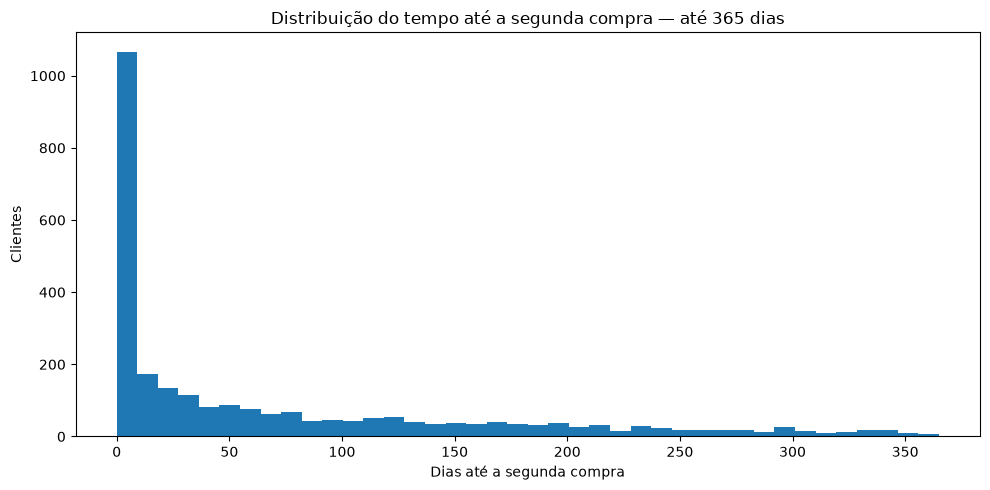

In [6]:
display(
    repeaters["days_to_second"]
    .describe(
        percentiles=[
            .10, .25, .50, .75, .90, .95
        ]
    )
    .round(2)
)

plot_days = repeaters.loc[
    repeaters["days_to_second"].le(365),
    "days_to_second"
]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(plot_days, bins=40)
ax.set_title(
    "Distribuição do tempo até a segunda compra — até 365 dias"
)
ax.set_xlabel("Dias até a segunda compra")
ax.set_ylabel("Clientes")

plt.tight_layout()
plt.show()


## 4. Recompra ajustada por janela de observação

Para uma janela de `H` dias:

- **Elegível**: primeira compra entregue ocorreu pelo menos `H` dias antes do fim da base;
- **Recompra H dias**: segunda compra entregue ocorreu até `H` dias após a primeira.

Essa definição reduz o viés de censura à direita e é a métrica recomendada para comparações de comportamento.


In [7]:
HORIZONS = [30, 60, 90, 180]

window_rows = []

for horizon in HORIZONS:
    eligible_col = f"eligible_{horizon}d"
    target_col = f"repurchase_{horizon}d"

    customer_repurchase[eligible_col] = (
        customer_repurchase["first_purchase"]
        <= dataset_end - pd.Timedelta(days=horizon)
    )

    customer_repurchase[target_col] = (
        customer_repurchase["second_purchase"].notna()
        & (
            customer_repurchase["second_purchase"]
            <= customer_repurchase["first_purchase"]
            + pd.Timedelta(days=horizon)
        )
    )

    eligible_mask = customer_repurchase[eligible_col]

    window_rows.append({
        "horizon_days": horizon,
        "eligible_customers": int(eligible_mask.sum()),
        "repurchasing_customers": int(
            customer_repurchase.loc[
                eligible_mask,
                target_col,
            ].sum()
        ),
        "repurchase_rate": (
            customer_repurchase.loc[
                eligible_mask,
                target_col,
            ].mean()
        ),
    })

repurchase_window_summary = pd.DataFrame(window_rows)

display(repurchase_window_summary)


,horizon_days,eligible_customers,repurchasing_customers,repurchase_rate
0,30,86772,1373,0.0158
1,60,81203,1584,0.0195
2,90,75320,1714,0.0228
3,180,55907,1736,0.0311


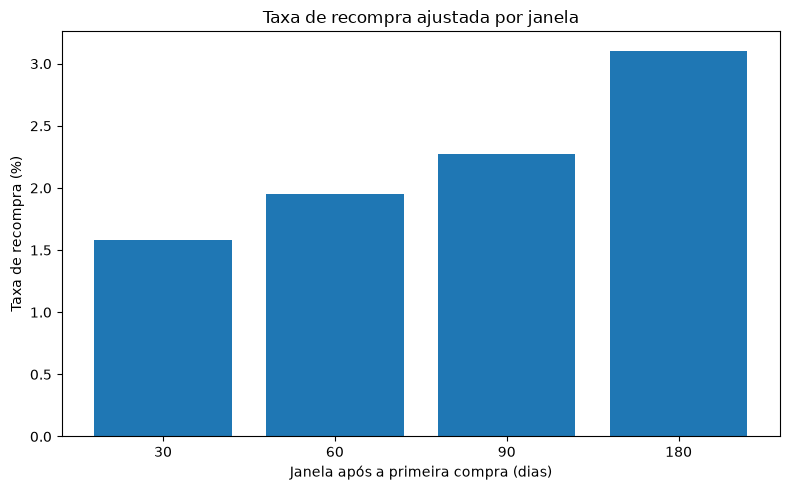

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    repurchase_window_summary["horizon_days"].astype(str),
    repurchase_window_summary["repurchase_rate"] * 100,
)

ax.set_title(
    "Taxa de recompra ajustada por janela"
)
ax.set_xlabel(
    "Janela após a primeira compra (dias)"
)
ax.set_ylabel(
    "Taxa de recompra (%)"
)

plt.tight_layout()
plt.show()


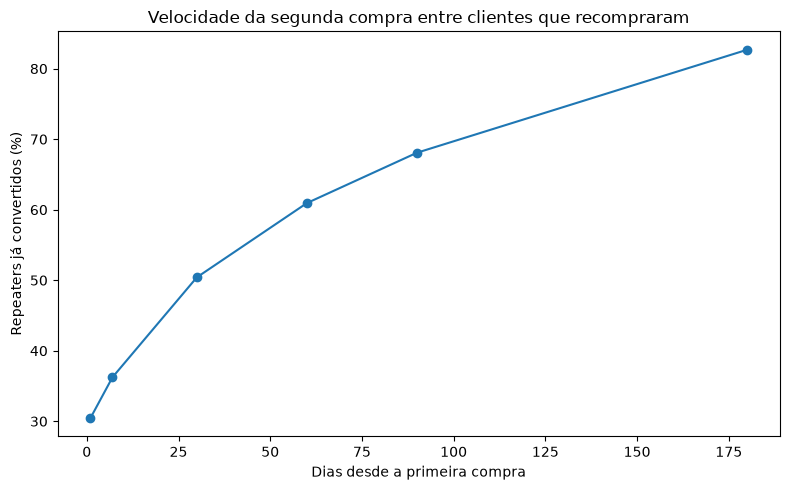

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    repurchase_speed_summary["horizon_days"],
    repurchase_speed_summary[
        "share_repeaters_within_horizon"
    ] * 100,
    marker="o",
)

ax.set_title(
    "Velocidade da segunda compra entre clientes que recompraram"
)
ax.set_xlabel(
    "Dias desde a primeira compra"
)
ax.set_ylabel(
    "Repeaters já convertidos (%)"
)

plt.tight_layout()
plt.show()


## 5. Enriquecimento da primeira compra — pagamento

O Notebook 02 já definiu o `primary_payment_type` como o meio de maior valor financeiro dentro do pedido.

Esse output é reutilizado aqui para evitar duplicação de lógica.

Para análises de parcelamento, usaremos apenas pedidos cujo meio principal é cartão de crédito e com `installment_max >= 1`.


In [10]:
required_payment_cols = {
    "order_id",
    "order_payment_value",
    "primary_payment_type",
    "installment_max",
    "payment_record_count",
    "payment_type_count",
}

missing_payment_cols = required_payment_cols.difference(
    payment_behavior.columns
)

if missing_payment_cols:
    raise ValueError(
        "Colunas ausentes em payment_behavior_order_level.csv: "
        f"{sorted(missing_payment_cols)}"
    )

payment_features = (
    payment_behavior[
        [
            "order_id",
            "order_payment_value",
            "primary_payment_type",
            "installment_max",
            "payment_record_count",
            "payment_type_count",
        ]
    ]
    .copy()
)

# Tipagem explícita: preserva <NA> sem misturar float NaN com strings.
payment_features["primary_payment_type"] = (
    payment_features["primary_payment_type"]
    .astype("string")
)

display(payment_features.head())


,order_id,order_payment_value,primary_payment_type,installment_max,payment_record_count,payment_type_count
0,00010242fe8c5a6d1ba2dd792cb16214,72.1900,credit_card,2,1,1
1,00018f77f2f0320c557190d7a144bdd3,259.8300,credit_card,3,1,1
2,000229ec398224ef6ca0657da4fc703e,216.8700,credit_card,5,1,1
3,00024acbcdf0a6daa1e931b038114c75,25.7800,credit_card,2,1,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.0400,credit_card,3,1,1


## 6. Enriquecimento da primeira compra — categoria

In [11]:
product_category = (
    products
    .merge(
        category_translation,
        on="product_category_name",
        how="left",
    )
)

product_category["category"] = (
    product_category["product_category_name_english"]
    .fillna(product_category["product_category_name"])
    .fillna("unknown")
)

items_enriched = (
    order_items
    .merge(
        product_category[
            ["product_id", "category"]
        ],
        on="product_id",
        how="left",
        validate="many_to_one",
    )
)

items_enriched["category"] = (
    items_enriched["category"]
    .fillna("unknown")
)

order_category_value = (
    items_enriched
    .groupby(
        ["order_id", "category"],
        as_index=False,
    )["price"]
    .sum()
)

category_idx = (
    order_category_value
    .groupby("order_id")["price"]
    .idxmax()
)

order_dominant_category = (
    order_category_value.loc[
        category_idx,
        ["order_id", "category"],
    ]
    .rename(
        columns={
            "category": "dominant_category"
        }
    )
)

display(order_dominant_category.head())


,order_id,dominant_category
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,pet_shop
2,000229ec398224ef6ca0657da4fc703e,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,garden_tools


In [12]:
customer_repurchase = (
    customer_repurchase
    .merge(
        payment_features.rename(
            columns={"order_id": "first_order_id"}
        ),
        on="first_order_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        order_dominant_category.rename(
            columns={"order_id": "first_order_id"}
        ),
        on="first_order_id",
        how="left",
        validate="one_to_one",
    )
)

customer_repurchase["dominant_category"] = (
    customer_repurchase["dominant_category"]
    .fillna("unknown")
)

customer_repurchase["first_purchase_month"] = (
    customer_repurchase["first_purchase"]
    .dt.to_period("M")
    .astype(str)
)

customer_repurchase["first_purchase_dow"] = (
    customer_repurchase["first_purchase"]
    .dt.day_name()
)

customer_repurchase["first_purchase_hour"] = (
    customer_repurchase["first_purchase"]
    .dt.hour
)

customer_repurchase["freight_ratio"] = np.where(
    customer_repurchase[
        "first_order_payment_value"
    ].notna()
    & customer_repurchase[
        "first_order_payment_value"
    ].gt(0),
    customer_repurchase[
        "first_order_freight_value"
    ]
    / customer_repurchase[
        "first_order_payment_value"
    ],
    np.nan,
)

display(customer_repurchase.head())


,first_order_id,customer_id,order_status,first_purchase,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,first_order_payment_value,payment_count,first_order_item_count,first_order_product_value,first_order_freight_value,first_order_distinct_products,first_order_distinct_sellers,order_number,second_order_id,second_purchase,repeat_customer,days_to_second,eligible_30d,repurchase_30d,eligible_60d,repurchase_60d,eligible_90d,repurchase_90d,eligible_180d,repurchase_180d,order_payment_value,primary_payment_type,installment_max,payment_record_count,payment_type_count,dominant_category,first_purchase_month,first_purchase_dow,first_purchase_hour,freight_ratio
0,e22acc9c116caa3f2b7121bbb380d08e,fadbb3709178fc513abc1b2670aa1ad2,delivered,2018-05-10 10:56:27,2018-05-10 11:11:18,2018-05-12 08:18:00,2018-05-16 20:48:37,2018-05-21,0000366f3b9a7992bf8c76cfdf3221e2,141.9000,1.0000,1.0000,129.9000,12.0000,1.0000,1.0000,1,NaN,NaT,False,NaN,True,False,True,False,True,False,False,False,141.9000,credit_card,8.0000,1.0000,1.0000,bed_bath_table,2018-05,Thursday,10,0.0846
1,3594e05a005ac4d06a72673270ef9ec9,4cb282e167ae9234755102258dd52ee8,delivered,2018-05-07 11:11:27,2018-05-07 18:25:44,2018-05-09 12:18:00,2018-05-10 18:02:42,2018-05-15,0000b849f77a49e4a4ce2b2a4ca5be3f,27.1900,1.0000,1.0000,18.9000,8.2900,1.0000,1.0000,1,NaN,NaT,False,NaN,True,False,True,False,True,False,False,False,27.1900,credit_card,1.0000,1.0000,1.0000,health_beauty,2018-05,Monday,11,0.3049
2,b33ec3b699337181488304f362a6b734,9b3932a6253894a02c1df9d19004239f,delivered,2017-03-10 21:05:03,2017-03-10 21:05:03,2017-03-13 12:58:30,2017-04-05 14:38:47,2017-04-07,0000f46a3911fa3c0805444483337064,86.2200,1.0000,1.0000,69.0000,17.2200,1.0000,1.0000,1,NaN,NaT,False,NaN,True,False,True,False,True,False,True,False,86.2200,credit_card,8.0000,1.0000,1.0000,stationery,2017-03,Friday,21,0.1997
3,41272756ecddd9a9ed0180413cc22fb6,914991f0c02ef0843c0e7010c819d642,delivered,2017-10-12 20:29:41,2017-10-12 20:49:17,2017-10-13 20:08:19,2017-11-01 21:23:05,2017-11-13,0000f6ccb0745a6a4b88665a16c9f078,43.6200,1.0000,1.0000,25.9900,17.6300,1.0000,1.0000,1,NaN,NaT,False,NaN,True,False,True,False,True,False,True,False,43.6200,credit_card,4.0000,1.0000,1.0000,telephony,2017-10,Thursday,20,0.4042
4,d957021f1127559cd947b62533f484f7,47227568b10f5f58a524a75507e6992c,delivered,2017-11-14 19:45:42,2017-11-14 20:06:52,2017-11-16 19:52:10,2017-11-27 23:08:56,2017-12-05,0004aac84e0df4da2b147fca70cf8255,196.8900,1.0000,1.0000,180.0000,16.8900,1.0000,1.0000,1,NaN,NaT,False,NaN,True,False,True,False,True,False,True,False,196.8900,credit_card,6.0000,1.0000,1.0000,telephony,2017-11,Tuesday,19,0.0858


## 7. Qualidade das variáveis financeiras da primeira compra

In [13]:
first_order_payment_quality = pd.Series({
    "customers":
        len(customer_repurchase),
    "missing_first_order_payment_value":
        int(
            customer_repurchase[
                "first_order_payment_value"
            ].isna().sum()
        ),
    "non_positive_first_order_payment_value":
        int(
            customer_repurchase[
                "first_order_payment_value"
            ].le(0).sum()
        ),
    "missing_primary_payment_type":
        int(
            customer_repurchase[
                "primary_payment_type"
            ].isna().sum()
        ),
})

first_order_payment_quality


customers                                 93358
missing_first_order_payment_value             1
non_positive_first_order_payment_value        0
missing_primary_payment_type                  1
dtype: int64

Clientes com valor de pagamento ausente ou não positivo continuam válidos para a análise geral de recompra, mas são excluídos das análises específicas de ticket e `freight_ratio`.

Isso evita interpretar ausência de informação como compra de valor zero.


## 8. Meio principal de pagamento × recompra em 90 dias

A janela de **90 dias** será usada como referência principal porque equilibra:

- tempo suficiente para capturar uma parcela relevante das segundas compras;
- população elegível ainda representativa;
- utilidade operacional para ações de CRM.

A escolha de 90 dias é uma **decisão analítica e operacional**, e não uma propriedade universal do negócio.

### Governança do meio de pagamento

Clientes sem `primary_payment_type` conhecido permanecem na base e na tabela de qualidade, para que a ausência não seja escondida.

Na comparação visual entre meios de pagamento, esses registros são excluídos porque não constituem uma categoria de negócio observada. Nenhum valor ausente é transformado artificialmente em `boleto`, `credit_card`, `voucher` ou `debit_card`.


In [14]:
eligible_90 = (
    customer_repurchase.loc[
        customer_repurchase["eligible_90d"]
    ]
    .copy()
)

# Garantir representação categórica consistente, preservando ausentes como <NA>.
eligible_90["primary_payment_type"] = (
    eligible_90["primary_payment_type"]
    .astype("string")
)

repurchase_by_payment_type_90d = (
    eligible_90
    .groupby(
        "primary_payment_type",
        dropna=False,
        observed=True,
    )
    .agg(
        customers=(
            "customer_unique_id",
            "size",
        ),
        repurchasers_90d=(
            "repurchase_90d",
            "sum",
        ),
        repurchase_rate_90d=(
            "repurchase_90d",
            "mean",
        ),
        avg_first_ticket=(
            "first_order_payment_value",
            "mean",
        ),
    )
    .reset_index()
    .sort_values(
        "repurchase_rate_90d",
        ascending=False,
        na_position="last",
    )
)

display(repurchase_by_payment_type_90d)

print(
    "Clientes elegíveis sem meio principal conhecido:",
    int(
        eligible_90[
            "primary_payment_type"
        ].isna().sum()
    ),
)


,primary_payment_type,customers,repurchasers_90d,repurchase_rate_90d,avg_first_ticket
3,voucher,2389,61,0.0255,116.0532
1,credit_card,56848,1293,0.0227,166.2711
0,boleto,15303,343,0.0224,144.4438
2,debit_card,779,17,0.0218,105.1394
4,<NA>,1,0,0.0000,NaN


Clientes elegíveis sem meio principal conhecido: 1


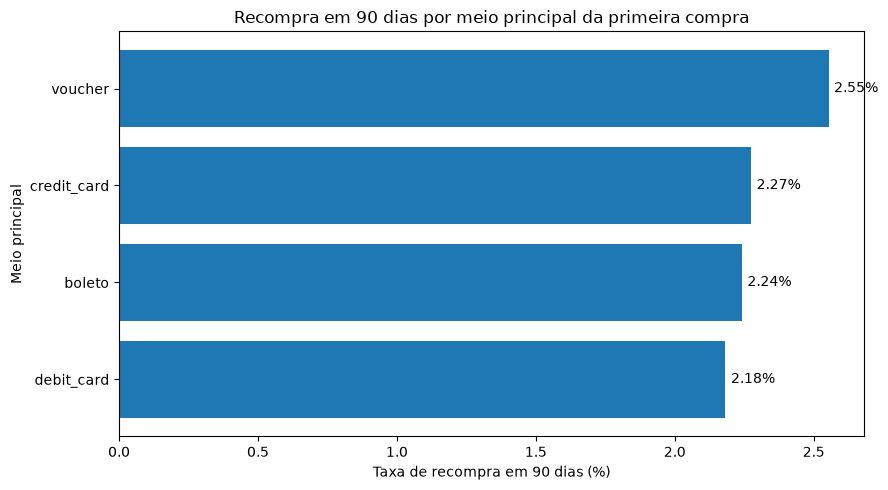

In [15]:
plot_data = (
    repurchase_by_payment_type_90d
    .dropna(
        subset=[
            "primary_payment_type",
            "repurchase_rate_90d",
        ]
    )
    .copy()
)

plot_data["primary_payment_type"] = (
    plot_data["primary_payment_type"]
    .astype(str)
)

plot_data["repurchase_rate_90d"] = pd.to_numeric(
    plot_data["repurchase_rate_90d"],
    errors="coerce",
)

plot_data = (
    plot_data
    .dropna(
        subset=["repurchase_rate_90d"]
    )
    .sort_values(
        "repurchase_rate_90d"
    )
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9, 5))

labels = plot_data[
    "primary_payment_type"
].to_numpy(dtype=str)

values = (
    plot_data[
        "repurchase_rate_90d"
    ]
    .mul(100)
    .to_numpy(dtype=float)
)

ax.barh(
    labels,
    values,
)

ax.set_title(
    "Recompra em 90 dias por meio principal da primeira compra"
)
ax.set_xlabel(
    "Taxa de recompra em 90 dias (%)"
)
ax.set_ylabel(
    "Meio principal"
)

for i, value in enumerate(values):
    ax.text(
        value + 0.02,
        i,
        f"{value:.2f}%",
        va="center",
    )

plt.tight_layout()
plt.show()


## 9. Cartão de crédito — parcelamento × recompra

A análise de parcelamento é restrita aos pedidos cujo meio principal é `credit_card` e que possuem `installment_max >= 1`.

Isso mantém consistência com a governança adotada no Notebook 02.


In [16]:
eligible_90_credit = (
    eligible_90.loc[
        eligible_90[
            "primary_payment_type"
        ].eq("credit_card")
        & eligible_90[
            "installment_max"
        ].ge(1)
    ]
    .copy()
)

installment_bins = [
    0,
    1,
    3,
    6,
    9,
    12,
    np.inf,
]

installment_labels = [
    "1x",
    "2–3x",
    "4–6x",
    "7–9x",
    "10–12x",
    "13+x",
]

eligible_90_credit["installment_band"] = pd.cut(
    eligible_90_credit["installment_max"],
    bins=installment_bins,
    labels=installment_labels,
    include_lowest=True,
)

repurchase_by_installment = (
    eligible_90_credit
    .groupby(
        "installment_band",
        observed=True,
    )
    .agg(
        customers=(
            "customer_unique_id",
            "size",
        ),
        repurchasers_90d=(
            "repurchase_90d",
            "sum",
        ),
        repurchase_rate_90d=(
            "repurchase_90d",
            "mean",
        ),
        avg_first_ticket=(
            "first_order_payment_value",
            "mean",
        ),
    )
    .reset_index()
)

display(repurchase_by_installment)


,installment_band,customers,repurchasers_90d,repurchase_rate_90d,avg_first_ticket
0,1x,18024,344,0.0191,101.5803
1,2–3x,17278,381,0.0221,134.0095
2,4–6x,12302,282,0.0229,179.6285
3,7–9x,4791,145,0.0303,269.5036
4,10–12x,4325,135,0.0312,404.3829
5,13+x,126,6,0.0476,442.4820


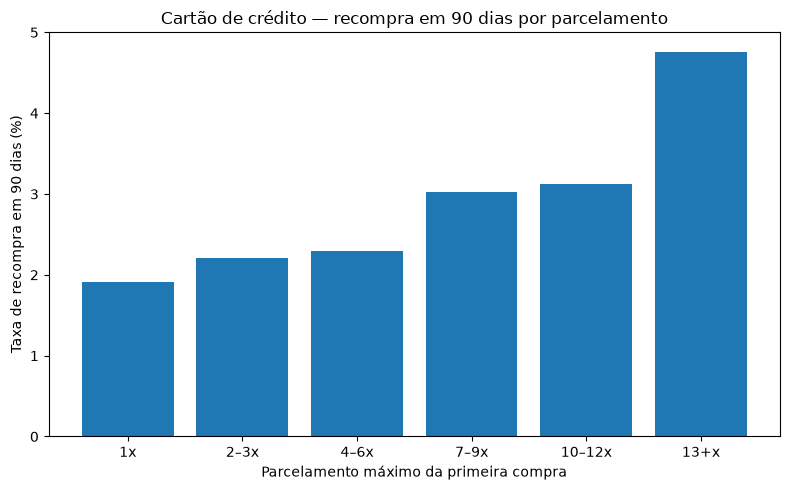

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    repurchase_by_installment[
        "installment_band"
    ].astype(str),
    repurchase_by_installment[
        "repurchase_rate_90d"
    ] * 100,
)

ax.set_title(
    "Cartão de crédito — recompra em 90 dias por parcelamento"
)
ax.set_xlabel(
    "Parcelamento máximo da primeira compra"
)
ax.set_ylabel(
    "Taxa de recompra em 90 dias (%)"
)

plt.tight_layout()
plt.show()


## 10. Ticket da primeira compra × recompra

Para evitar faixas arbitrárias, o ticket é dividido em quintis **dentro da população elegível para 90 dias e com ticket válido**.


In [18]:
eligible_90_ticket = (
    eligible_90.loc[
        eligible_90[
            "first_order_payment_value"
        ].notna()
        & eligible_90[
            "first_order_payment_value"
        ].gt(0)
    ]
    .copy()
)

eligible_90_ticket["ticket_quintile"] = pd.qcut(
    eligible_90_ticket[
        "first_order_payment_value"
    ],
    q=5,
    labels=[
        "Q1 — menor",
        "Q2",
        "Q3",
        "Q4",
        "Q5 — maior",
    ],
    duplicates="drop",
)

repurchase_by_ticket = (
    eligible_90_ticket
    .groupby(
        "ticket_quintile",
        observed=True,
    )
    .agg(
        customers=(
            "customer_unique_id",
            "size",
        ),
        repurchasers_90d=(
            "repurchase_90d",
            "sum",
        ),
        repurchase_rate_90d=(
            "repurchase_90d",
            "mean",
        ),
        avg_first_ticket=(
            "first_order_payment_value",
            "mean",
        ),
    )
    .reset_index()
)

display(repurchase_by_ticket)


,ticket_quintile,customers,repurchasers_90d,repurchase_rate_90d,avg_first_ticket
0,Q1 — menor,15068,369,0.0245,39.2012
1,Q2,15137,329,0.0217,69.0131
2,Q3,14989,412,0.0275,105.3601
3,Q4,15063,278,0.0185,159.9898
4,Q5 — maior,15062,326,0.0216,424.7280


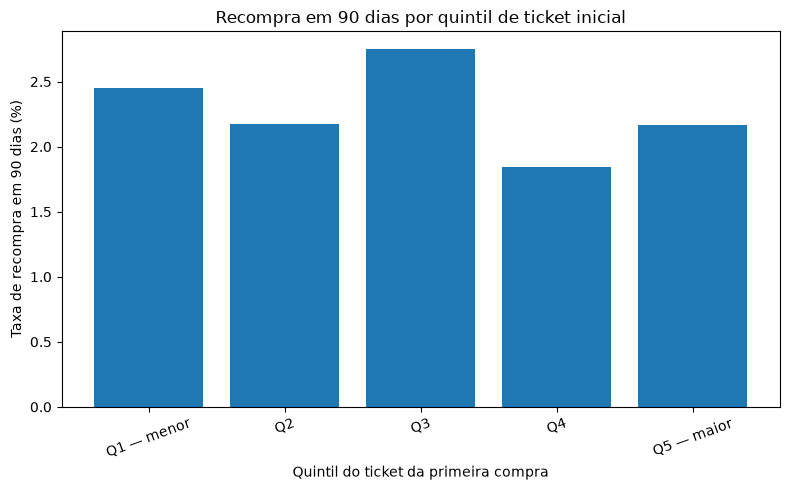

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    repurchase_by_ticket[
        "ticket_quintile"
    ].astype(str),
    repurchase_by_ticket[
        "repurchase_rate_90d"
    ] * 100,
)

ax.set_title(
    "Recompra em 90 dias por quintil de ticket inicial"
)
ax.set_xlabel(
    "Quintil do ticket da primeira compra"
)
ax.set_ylabel(
    "Taxa de recompra em 90 dias (%)"
)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 11. Categoria da primeira compra × recompra em 90 dias

Para reduzir ruído de amostras pequenas, a comparação executiva destaca categorias com pelo menos **300 clientes elegíveis**.


In [20]:
repurchase_by_category = (
    eligible_90
    .groupby("dominant_category")
    .agg(
        customers=(
            "customer_unique_id",
            "size",
        ),
        repurchasers_90d=(
            "repurchase_90d",
            "sum",
        ),
        repurchase_rate_90d=(
            "repurchase_90d",
            "mean",
        ),
        avg_first_ticket=(
            "first_order_payment_value",
            "mean",
        ),
    )
    .reset_index()
)

category_min_sample = 300

category_comparison = (
    repurchase_by_category.loc[
        repurchase_by_category[
            "customers"
        ].ge(category_min_sample)
    ]
    .sort_values(
        "repurchase_rate_90d",
        ascending=False,
    )
)

display(category_comparison.head(20))


,dominant_category,customers,repurchasers_90d,repurchase_rate_90d,avg_first_ticket
44,home_appliances,494,38,0.0769,137.2451
28,fashion_bags_accessories,1434,63,0.0439,99.7655
7,bed_bath_table,7126,282,0.0396,133.1213
39,furniture_decor,4976,175,0.0352,137.5543
67,sports_leisure,6040,173,0.0286,149.6393
17,construction_tools_construction,388,9,0.0232,234.4116
43,health_beauty,6177,140,0.0227,162.5476
15,computers_accessories,5223,114,0.0218,163.1978
61,pet_shop,1185,24,0.0203,143.5611
65,small_appliances,495,10,0.0202,322.6135


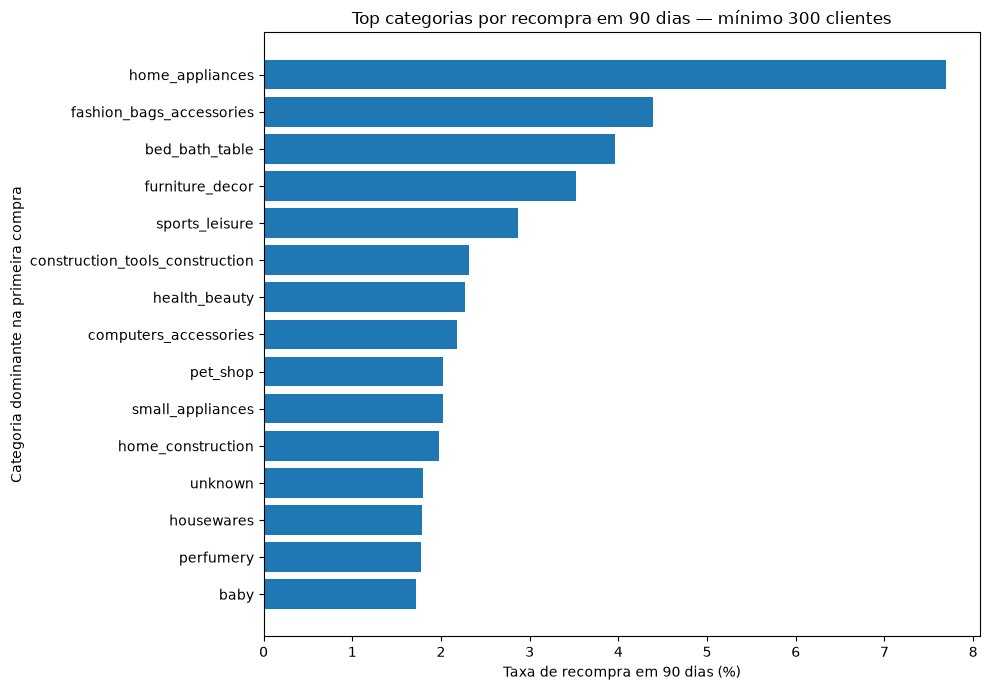

In [21]:
plot_cat = (
    category_comparison
    .head(15)
    .sort_values(
        "repurchase_rate_90d"
    )
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    plot_cat["dominant_category"],
    plot_cat["repurchase_rate_90d"] * 100,
)

ax.set_title(
    f"Top categorias por recompra em 90 dias — mínimo {category_min_sample} clientes"
)
ax.set_xlabel(
    "Taxa de recompra em 90 dias (%)"
)
ax.set_ylabel(
    "Categoria dominante na primeira compra"
)

plt.tight_layout()
plt.show()


## 12. Mesma categoria ou expansão de relacionamento?

In [22]:
second_category = (
    order_dominant_category
    .rename(columns={
        "order_id": "second_order_id",
        "dominant_category": "second_dominant_category",
    })
)

repeat_category = (
    customer_repurchase.loc[
        customer_repurchase[
            "repeat_customer"
        ],
        [
            "customer_unique_id",
            "dominant_category",
            "second_order_id",
            "days_to_second",
        ],
    ]
    .merge(
        second_category,
        on="second_order_id",
        how="left",
        validate="many_to_one",
    )
)

repeat_category["second_dominant_category"] = (
    repeat_category[
        "second_dominant_category"
    ]
    .fillna("unknown")
)

repeat_category["same_category"] = (
    repeat_category["dominant_category"]
    == repeat_category["second_dominant_category"]
)

same_category_rate = (
    repeat_category["same_category"].mean()
)

repeat_category_90 = (
    repeat_category.loc[
        repeat_category[
            "days_to_second"
        ].le(90)
    ]
    .copy()
)

same_category_rate_90d = (
    repeat_category_90[
        "same_category"
    ].mean()
)

print(
    "Mesma categoria — todos os repeaters:",
    f"{same_category_rate:.2%}"
)

print(
    "Mesma categoria — repeaters em até 90 dias:",
    f"{same_category_rate_90d:.2%}"
)


Mesma categoria — todos os repeaters: 45.98%
Mesma categoria — repeaters em até 90 dias: 57.00%


In [23]:
category_transition = (
    repeat_category
    .groupby(
        [
            "dominant_category",
            "second_dominant_category",
        ]
    )
    .size()
    .reset_index(
        name="customers"
    )
    .sort_values(
        "customers",
        ascending=False,
    )
)

transition_summary = pd.DataFrame({
    "transition_type": [
        "Mesma categoria",
        "Categoria diferente",
    ],
    "customers": [
        int(
            repeat_category[
                "same_category"
            ].sum()
        ),
        int(
            (
                ~repeat_category[
                    "same_category"
                ]
            ).sum()
        ),
    ],
})

transition_summary["share"] = (
    transition_summary["customers"]
    / transition_summary["customers"].sum()
)

display(category_transition.head(20))
display(transition_summary)


,dominant_category,second_dominant_category,customers
66,bed_bath_table,bed_bath_table,222
559,sports_leisure,sports_leisure,160
365,health_beauty,health_beauty,138
292,furniture_decor,furniture_decor,118
113,computers_accessories,computers_accessories,117
667,watches_gifts,watches_gifts,59
421,housewares,housewares,53
383,home_appliances,home_appliances,49
224,fashion_bags_accessories,fashion_bags_accessories,44
599,telephony,telephony,42


,transition_type,customers,share
0,Mesma categoria,1288,0.4598
1,Categoria diferente,1513,0.5402


## 13. Coorte de aquisição × recompra em 90 dias

In [24]:
cohort_90d = (
    customer_repurchase.loc[
        customer_repurchase["eligible_90d"]
    ]
    .groupby(
        "first_purchase_month"
    )
    .agg(
        acquired_customers=(
            "customer_unique_id",
            "size",
        ),
        repurchasers_90d=(
            "repurchase_90d",
            "sum",
        ),
        repurchase_rate_90d=(
            "repurchase_90d",
            "mean",
        ),
        avg_first_ticket=(
            "first_order_payment_value",
            "mean",
        ),
    )
    .reset_index()
    .sort_values(
        "first_purchase_month"
    )
)

display(cohort_90d.tail(18))


,first_purchase_month,acquired_customers,repurchasers_90d,repurchase_rate_90d,avg_first_ticket
2,2016-12,1,1,1.0000,19.6200
3,2017-01,717,26,0.0363,173.7982
4,2017-02,1628,28,0.0172,164.7097
5,2017-03,2503,62,0.0248,163.6477
6,2017-04,2256,48,0.0213,170.0463
7,2017-05,3451,98,0.0284,159.8338
8,2017-06,3037,86,0.0283,157.4396
9,2017-07,3752,97,0.0259,146.5829
10,2017-08,4057,112,0.0276,153.8894
11,2017-09,4004,114,0.0285,169.9786


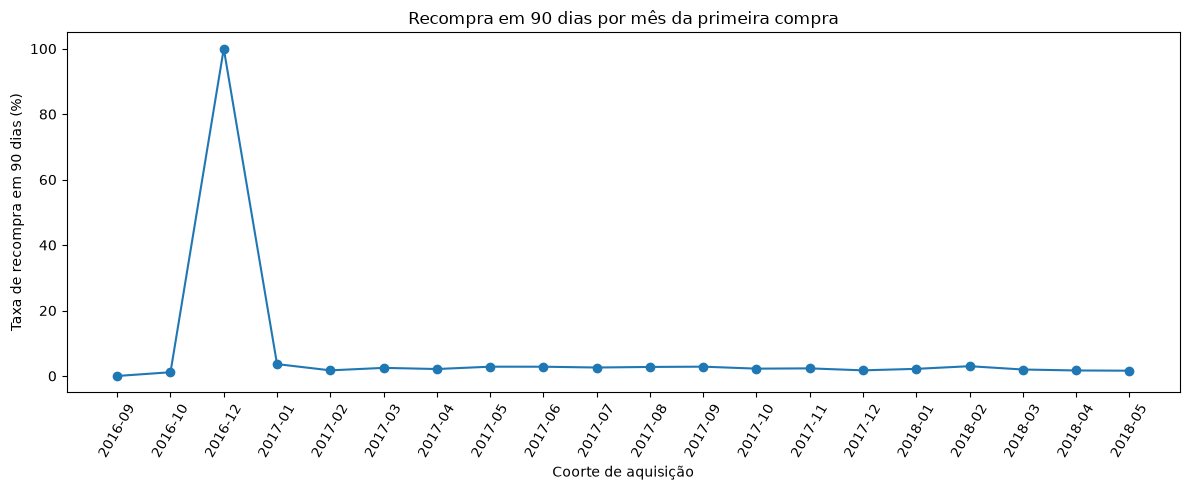

In [25]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    cohort_90d["first_purchase_month"],
    cohort_90d["repurchase_rate_90d"] * 100,
    marker="o",
)

ax.set_title(
    "Recompra em 90 dias por mês da primeira compra"
)
ax.set_xlabel(
    "Coorte de aquisição"
)
ax.set_ylabel(
    "Taxa de recompra em 90 dias (%)"
)

plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


## 14. Base para modelagem preditiva de recompra em 90 dias

### Momento operacional do score

A população de modelagem é formada por consumidores **após a conclusão da primeira compra entregue**.

Portanto, o cenário operacional assumido é:

```text
Primeira compra
      ↓
Pedido entregue
      ↓
Cliente entra na população elegível
      ↓
Score de propensão à segunda compra
      ↓
Janela de 90 dias
```

As features utilizadas são originadas no primeiro pedido entregue.

Nenhuma informação sobre compras posteriores é usada como feature.

O target é `repurchase_90d`.


In [26]:
model_columns = [
    "customer_unique_id",
    "first_order_id",
    "first_purchase",
    "first_order_payment_value",
    "first_order_product_value",
    "first_order_freight_value",
    "first_order_item_count",
    "first_order_distinct_products",
    "first_order_distinct_sellers",
    "freight_ratio",
    "primary_payment_type",
    "installment_max",
    "payment_record_count",
    "payment_type_count",
    "dominant_category",
    "first_purchase_month",
    "first_purchase_dow",
    "first_purchase_hour",
    "repurchase_90d",
]

available_model_columns = [
    c for c in model_columns
    if c in customer_repurchase.columns
]

repurchase_90d_model_base = (
    customer_repurchase.loc[
        customer_repurchase[
            "eligible_90d"
        ],
        available_model_columns,
    ]
    .copy()
    .sort_values(
        "first_purchase"
    )
    .reset_index(drop=True)
)

print(
    "Model base:",
    repurchase_90d_model_base.shape
)

print(
    "Target rate:",
    f"{repurchase_90d_model_base['repurchase_90d'].mean():.2%}"
)

display(
    repurchase_90d_model_base.head()
)


Model base: (75320, 19)
Target rate: 2.28%


,customer_unique_id,first_order_id,first_purchase,first_order_payment_value,first_order_product_value,first_order_freight_value,first_order_item_count,first_order_distinct_products,first_order_distinct_sellers,freight_ratio,primary_payment_type,installment_max,payment_record_count,payment_type_count,dominant_category,first_purchase_month,first_purchase_dow,first_purchase_hour,repurchase_90d
0,830d5b7aaa3b6f1e9ad63703bec97d23,bfbd0f9bdef84302105ad712db648a6c,2016-09-15 12:16:38,NaN,134.9700,8.4900,3.0000,1.0000,1.0000,NaN,<NA>,NaN,NaN,NaN,health_beauty,2016-09,Thursday,12,False
1,32ea3bdedab835c3aa6cb68ce66565ef,3b697a20d9e427646d92567910af6d57,2016-10-03 09:44:50,45.4600,29.9000,15.5600,1.0000,1.0000,1.0000,0.3423,boleto,1.0000,1.0000,1.0000,watches_gifts,2016-10,Monday,9,False
2,2f64e403852e6893ae37485d5fcacdaf,be5bc2f0da14d8071e2d45451ad119d9,2016-10-03 16:56:50,39.0900,21.9000,17.1900,1.0000,1.0000,1.0000,0.4398,boleto,1.0000,1.0000,1.0000,sports_leisure,2016-10,Monday,16,False
3,61db744d2f835035a5625b59350c6b63,a41c8759fbe7aab36ea07e038b2d4465,2016-10-03 21:13:36,53.7300,36.4900,17.2400,1.0000,1.0000,1.0000,0.3209,boleto,1.0000,1.0000,1.0000,sports_leisure,2016-10,Monday,21,False
4,8d3a54507421dbd2ce0a1d58046826e0,d207cc272675637bfed0062edffd0818,2016-10-03 22:06:03,133.4600,119.9000,13.5600,1.0000,1.0000,1.0000,0.1016,credit_card,6.0000,1.0000,1.0000,furniture_decor,2016-10,Monday,22,False


### Validação temporal recomendada

O Notebook 04 **não define o split final de treino/validação/teste**.

Essa responsabilidade fica concentrada no Notebook 06, que deverá:

- ordenar por `first_purchase`;
- usar coortes temporais;
- evitar dividir a mesma coorte entre treino e teste;
- manter somente clientes com janela de 90 dias completa;
- tratar o forte desbalanceamento do target.

Isso evita duplicação de regras entre notebooks.


In [27]:
model_temporal_profile = (
    repurchase_90d_model_base
    .assign(
        acquisition_month=
            repurchase_90d_model_base[
                "first_purchase"
            ]
            .dt.to_period("M")
            .astype(str)
    )
    .groupby(
        "acquisition_month"
    )
    .agg(
        customers=(
            "customer_unique_id",
            "size",
        ),
        repurchasers_90d=(
            "repurchase_90d",
            "sum",
        ),
        repurchase_rate_90d=(
            "repurchase_90d",
            "mean",
        ),
    )
    .reset_index()
)

display(model_temporal_profile.tail(18))


,acquisition_month,customers,repurchasers_90d,repurchase_rate_90d
2,2016-12,1,1,1.0000
3,2017-01,717,26,0.0363
4,2017-02,1628,28,0.0172
5,2017-03,2503,62,0.0248
6,2017-04,2256,48,0.0213
7,2017-05,3451,98,0.0284
8,2017-06,3037,86,0.0283
9,2017-07,3752,97,0.0259
10,2017-08,4057,112,0.0276
11,2017-09,4004,114,0.0285


## 15. KPIs executivos

In [28]:
median_days_to_second = (
    repeaters[
        "days_to_second"
    ].median()
)

share_repeaters_30d = (
    repeaters[
        "days_to_second"
    ].le(30).mean()
)

share_repeaters_90d = (
    repeaters[
        "days_to_second"
    ].le(90).mean()
)

row_90 = (
    repurchase_window_summary.loc[
        repurchase_window_summary[
            "horizon_days"
        ].eq(90)
    ]
    .iloc[0]
)

row_180 = (
    repurchase_window_summary.loc[
        repurchase_window_summary[
            "horizon_days"
        ].eq(180)
    ]
    .iloc[0]
)

executive_kpis = pd.DataFrame({
    "kpi": [
        "customers_delivered",
        "repeat_customers_any_time",
        "observed_repeat_rate",
        "median_days_to_second_purchase",
        "share_repeaters_within_30d",
        "share_repeaters_within_90d",
        "eligible_customers_90d",
        "repurchasers_90d",
        "repurchase_rate_90d_adjusted",
        "repurchase_rate_180d_adjusted",
        "same_category_share_second_purchase",
        "same_category_share_second_purchase_90d",
    ],
    "value": [
        len(customer_repurchase),
        int(
            customer_repurchase[
                "repeat_customer"
            ].sum()
        ),
        raw_repeat_rate,
        median_days_to_second,
        share_repeaters_30d,
        share_repeaters_90d,
        int(
            row_90[
                "eligible_customers"
            ]
        ),
        int(
            row_90[
                "repurchasing_customers"
            ]
        ),
        row_90[
            "repurchase_rate"
        ],
        row_180[
            "repurchase_rate"
        ],
        same_category_rate,
        same_category_rate_90d,
    ],
})

display(executive_kpis)


,kpi,value
0,customers_delivered,"93,358.0000"
1,repeat_customers_any_time,"2,801.0000"
2,observed_repeat_rate,0.0300
3,median_days_to_second_purchase,28.9802
4,share_repeaters_within_30d,0.5041
5,share_repeaters_within_90d,0.6808
6,eligible_customers_90d,"75,320.0000"
7,repurchasers_90d,"1,714.0000"
8,repurchase_rate_90d_adjusted,0.0228
9,repurchase_rate_180d_adjusted,0.0311


In [29]:
print("LEITURA EXECUTIVA")
print("-" * 80)

print(
    f"1. A taxa observada de clientes recorrentes é "
    f"{raw_repeat_rate:.2%}."
)

print(
    f"2. A recompra ajustada em 90 dias é "
    f"{row_90['repurchase_rate']:.2%} "
    f"e em 180 dias é "
    f"{row_180['repurchase_rate']:.2%}."
)

print(
    f"3. Entre quem recompra, a mediana até a segunda compra "
    f"é {median_days_to_second:.1f} dias."
)

print(
    f"4. {share_repeaters_30d:.1%} dos repeaters convertem "
    f"em até 30 dias e {share_repeaters_90d:.1%} "
    f"em até 90 dias."
)

print(
    f"5. Entre os repeaters em até 90 dias, "
    f"{same_category_rate_90d:.1%} permanecem "
    f"na mesma categoria dominante."
)

if share_repeaters_90d >= 0.50:
    print(
        "6. A maior parte das segundas compras observadas "
        "ocorre em até 90 dias, reforçando a relevância "
        "da janela pós-primeira compra."
    )
else:
    print(
        "6. Uma parcela relevante das segundas compras "
        "ocorre após 90 dias, sugerindo uma janela "
        "de relacionamento mais longa."
    )

print(
    "7. Diferenças por pagamento, parcelamento, ticket "
    "e categoria são associações, não evidência causal."
)


LEITURA EXECUTIVA
--------------------------------------------------------------------------------
1. A taxa observada de clientes recorrentes é 3.00%.
2. A recompra ajustada em 90 dias é 2.28% e em 180 dias é 3.11%.
3. Entre quem recompra, a mediana até a segunda compra é 29.0 dias.
4. 50.4% dos repeaters convertem em até 30 dias e 68.1% em até 90 dias.
5. Entre os repeaters em até 90 dias, 57.0% permanecem na mesma categoria dominante.
6. A maior parte das segundas compras observadas ocorre em até 90 dias, reforçando a relevância da janela pós-primeira compra.
7. Diferenças por pagamento, parcelamento, ticket e categoria são associações, não evidência causal.


## 16. Recomendações para storytelling executivo

### Tese 1 — O principal gargalo é transformar aquisição em relacionamento

A taxa observada de clientes recorrentes é baixa em relação ao tamanho da base, reforçando a dependência de aquisição contínua.

### Tese 2 — A janela pós-primeira compra é crítica

A concentração temporal das segundas compras deve orientar jornadas de CRM e ativação.

### Tese 3 — Categoria inicial importa

Categorias com maior taxa ajustada de recompra podem funcionar como portas de entrada para relacionamento. Categorias com alta aquisição, mas baixo retorno, podem exigir estratégias específicas de cross-sell.

### Tese 4 — Parte relevante das segundas compras permanece na mesma categoria

O percentual deve ser lido diretamente dos resultados do notebook, evitando afirmações estáticas.

### Tese 5 — Pagamento e parcelamento são sinais, não causas

Meio de pagamento, número de parcelas e ticket podem ser úteis como features de propensão, mas devem ser avaliados conjuntamente em um modelo multivariado.


## 17. Sanity checks

In [30]:
assert customer_repurchase[
    "customer_unique_id"
].is_unique, (
    "A base customer-level deve ter uma linha por cliente."
)

assert customer_repurchase[
    "first_order_id"
].is_unique, (
    "Primeiro pedido deveria ser único por cliente."
)

assert (
    customer_repurchase[
        "days_to_second"
    ]
    .dropna()
    .ge(0)
    .all()
), "Há segunda compra anterior à primeira."

assert (
    repurchase_90d_model_base[
        "repurchase_90d"
    ]
    .notna()
    .all()
), "Target de 90 dias não pode ser nulo."

assert (
    repurchase_90d_model_base[
        "first_purchase"
    ].max()
    <= dataset_end - pd.Timedelta(days=90)
), "Há cliente sem janela completa de 90 dias na model base."

assert (
    repurchase_window_summary[
        "repurchase_rate"
    ]
    .between(0, 1)
    .all()
), "Taxas fora do intervalo [0,1]."

for horizon in HORIZONS:
    eligible_col = f"eligible_{horizon}d"
    target_col = f"repurchase_{horizon}d"

    eligible_mask = (
        customer_repurchase[
            eligible_col
        ]
    )

    assert (
        customer_repurchase.loc[
            eligible_mask,
            "first_purchase",
        ]
        <= dataset_end
        - pd.Timedelta(days=horizon)
    ).all()

    assert (
        customer_repurchase.loc[
            eligible_mask,
            target_col,
        ]
        .isin([True, False])
        .all()
    )

assert (
    customer_repurchase.loc[
        customer_repurchase[
            "repurchase_30d"
        ],
        "repurchase_60d",
    ]
    .all()
)

assert (
    customer_repurchase.loc[
        customer_repurchase[
            "repurchase_60d"
        ],
        "repurchase_90d",
    ]
    .all()
)

assert (
    customer_repurchase.loc[
        customer_repurchase[
            "repurchase_90d"
        ],
        "repurchase_180d",
    ]
    .all()
)

assert (
    repurchase_90d_model_base[
        "customer_unique_id"
    ]
    .is_unique
), "Model base deve ter uma linha por cliente."

assert (
    repurchase_by_payment_type_90d[
        "repurchase_rate_90d"
    ]
    .dropna()
    .between(0, 1)
    .all()
), "Há taxa de recompra por pagamento fora de [0,1]."

assert (
    repurchase_by_payment_type_90d[
        "customers"
    ].sum()
    == len(eligible_90)
), (
    "A tabela por meio de pagamento deve contabilizar "
    "todos os clientes elegíveis, inclusive meio ausente."
)

known_payment_customers = (
    repurchase_by_payment_type_90d.loc[
        repurchase_by_payment_type_90d[
            "primary_payment_type"
        ].notna(),
        "customers",
    ].sum()
)

assert (
    known_payment_customers
    + eligible_90[
        "primary_payment_type"
    ].isna().sum()
    == len(eligible_90)
)

print(
    "Sanity checks concluídos com sucesso."
)


Sanity checks concluídos com sucesso.


## 18. Exportação das camadas analíticas

In [31]:
exports = {
    "repurchase_customer_level.csv":
        customer_repurchase,
    "repurchase_window_summary.csv":
        repurchase_window_summary,
    "repurchase_speed_summary.csv":
        repurchase_speed_summary,
    "repurchase_by_payment_type_90d.csv":
        repurchase_by_payment_type_90d,
    "repurchase_by_installments_90d.csv":
        repurchase_by_installment,
    "repurchase_by_ticket_90d.csv":
        repurchase_by_ticket,
    "repurchase_by_first_category_90d.csv":
        repurchase_by_category,
    "repurchase_category_transition.csv":
        category_transition,
    "repurchase_cohort_90d.csv":
        cohort_90d,
    "repurchase_90d_model_base.csv":
        repurchase_90d_model_base,
    "repurchase_model_temporal_profile.csv":
        model_temporal_profile,
    "repurchase_executive_kpis.csv":
        executive_kpis,
}

for filename, df in exports.items():
    path = PROCESSED_DIR / filename

    df.to_csv(
        path,
        index=False,
    )

    print(
        "Exportado:",
        path,
        df.shape,
    )


Exportado: c:\Users\F6363856\OneDrive - Banco do Brasil S.A\Área de Trabalho\Pós Data Analytics\1 entregavel\entregavel\data\processed\repurchase_customer_level.csv (93358, 39)
Exportado: c:\Users\F6363856\OneDrive - Banco do Brasil S.A\Área de Trabalho\Pós Data Analytics\1 entregavel\entregavel\data\processed\repurchase_window_summary.csv (4, 4)
Exportado: c:\Users\F6363856\OneDrive - Banco do Brasil S.A\Área de Trabalho\Pós Data Analytics\1 entregavel\entregavel\data\processed\repurchase_speed_summary.csv (6, 3)
Exportado: c:\Users\F6363856\OneDrive - Banco do Brasil S.A\Área de Trabalho\Pós Data Analytics\1 entregavel\entregavel\data\processed\repurchase_by_payment_type_90d.csv (5, 5)
Exportado: c:\Users\F6363856\OneDrive - Banco do Brasil S.A\Área de Trabalho\Pós Data Analytics\1 entregavel\entregavel\data\processed\repurchase_by_installments_90d.csv (6, 5)
Exportado: c:\Users\F6363856\OneDrive - Banco do Brasil S.A\Área de Trabalho\Pós Data Analytics\1 entregavel\entregavel\data\p

## Conclusão

O Notebook 04 transforma recorrência em uma métrica temporalmente comparável e prepara o projeto para duas frentes:

1. **Notebook 05 — Cohort Analysis:** retenção por mês de aquisição e evolução temporal.
2. **Notebook 06 — Repurchase Prediction:** previsão de recompra em 90 dias usando apenas sinais originados na primeira compra entregue e validação temporal.

A recomendação executiva central é medir e otimizar a **conversão da primeira para a segunda compra**, com atenção especial à janela de 30–90 dias, sempre distinguindo associação observada de relação causal.
